# Preparing Alpha Factors and Features to predict Stock Returns

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

# %matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from talib import RSI, BBANDS, MACD, ATR

In [2]:
MONTH = 21
YEAR = 12 * MONTH

START = '2010-01-01'
END = '2025-12-30'
path_data = os.path.join("..", "..", "data", "assets.h5")

In [3]:
sns.set_style('whitegrid')
idx = pd.IndexSlice

In [4]:
with pd.HDFStore(path_data) as store:
    prices = (store["stocks/chile"]
              .loc[idx[START : END, : ], :]
              .assign(Volume = lambda x : x.Volume.div(1000))
              .swaplevel()
              .sort_index()
              )
    
    stocks = (
        store["meta/chile"]
        .set_index("ticker")
        .loc[ : , ["sector", "marketCap", "ipoYear"]]
    )
    
stocks.head()

,sector,marketCap,ipoYear
ticker,,,
ABC.SN,Consumer Discretionary,7.058561e+10,2024
AGUAS-A.SN,Utilities & Energy,2.295713e+12,2000
ALMENDRAL.SN,Telecom & Technology,5.675538e+11,2000
ANTARCHILE.SN,Industrials,3.813507e+12,2000
AZUL-AZUL.SN,Consumer Discretionary,2.234167e+10,2008


In [5]:
prices.head()

Price               Open   High  Low  Close     Volume
Ticker Date                                           
ABC.SN 2024-07-23   9.36  10.00  9.3  9.827  14849.370
       2024-07-24  10.00  10.30  9.5  9.801  25823.660
       2024-07-25   9.90   9.90  9.8  9.800   3695.602
       2024-07-26   9.70   9.92  9.7  9.892   5669.528
       2024-07-29   9.70   9.92  9.7  9.892   5669.528

# Remove stocks with few observations

In [6]:
min_obs = 2 * 20 * 12 # 2 years

n_obs = prices.groupby(level='Ticker').size()
keep = n_obs[n_obs > min_obs].index
prices = prices.loc[idx[keep, :], :]

### Align price and meta data

In [7]:
stocks = stocks[~stocks.index.duplicated() & stocks.sector.notnull()]
stocks.sector = stocks.sector.str.lower().str.replace(" ", "_")
stocks.index.name = 'Ticker'

In [8]:
shared = (prices.index.get_level_values('Ticker').unique().intersection(stocks.index))
stocks = stocks.loc[shared, :]
prices = prices.loc[idx[shared, : ], :]

In [9]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 445227 entries, ('AGUAS-A.SN', Timestamp('2010-01-01 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-30 00:00:00'))
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    445227 non-null  float64
 1   High    445227 non-null  float64
 2   Low     445227 non-null  float64
 3   Close   445227 non-null  float64
 4   Volume  445227 non-null  float64
dtypes: float64(5)
memory usage: 18.4+ MB


In [ ]:
stocks.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, AGUAS-A.SN to ZOFRI.SN
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sector     117 non-null    string 
 1   marketCap  116 non-null    float64
 2   ipoYear    117 non-null    int64  
dtypes: float64(1), int64(1), string(1)
memory usage: 3.7+ KB


In [11]:
stocks.sector.value_counts()

sector
industrials               25
financials                19
utilities_&_energy        18
consumer_discretionary    14
consumer_staples          14
materials_&_mining        12
real_estate                7
telecom_&_technology       4
other                      2
healthcare                 2
Name: count, dtype: Int64

# Compute rolling average dollar volume

In [12]:
prices.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')

In [13]:
prices["peso_vol"] = prices[['Close', 'Volume']].prod(axis = 1)

In [14]:
prices["peso_vol_1m"] = (prices
                         .groupby('Ticker')['peso_vol']
                         .rolling(window=21)
                         .mean()
                         .reset_index(level=0, drop=True)
                         .values)

In [15]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 445227 entries, ('AGUAS-A.SN', Timestamp('2010-01-01 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-30 00:00:00'))
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Open         445227 non-null  float64
 1   High         445227 non-null  float64
 2   Low          445227 non-null  float64
 3   Close        445227 non-null  float64
 4   Volume       445227 non-null  float64
 5   peso_vol     445227 non-null  float64
 6   peso_vol_1m  442887 non-null  float64
dtypes: float64(7)
memory usage: 25.2+ MB


In [16]:
prices['peso_vol_rank'] = (prices.groupby('Date')
                             .peso_vol_1m
                             .rank(ascending=False))

In [17]:
prices.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 445227 entries, ('AGUAS-A.SN', Timestamp('2010-01-01 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-30 00:00:00'))
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Open           445227 non-null  float64
 1   High           445227 non-null  float64
 2   Low            445227 non-null  float64
 3   Close          445227 non-null  float64
 4   Volume         445227 non-null  float64
 5   peso_vol       445227 non-null  float64
 6   peso_vol_1m    442887 non-null  float64
 7   peso_vol_rank  442887 non-null  float64
dtypes: float64(8)
memory usage: 28.6+ MB


# Add some Basic Factors

## Compute the relative strenth index

In [18]:
prices['rsi'] = (
    prices.groupby(level='Ticker')['Close']
          .transform(lambda x: RSI(x, timeperiod=14))
)

In [19]:
prices.index.get_level_values('Ticker').unique()

Index(['AGUAS-A.SN', 'ALMENDRAL.SN', 'ANTARCHILE.SN', 'AZUL-AZUL.SN',
       'BANVIDA.SN', 'BCI.SN', 'BESALCO.SN', 'BINT.SN', 'BLUMAR.SN',
       'BSANTANDER.SN',
       ...
       'SOQUICOM.SN', 'SQM', 'TRICAHUE.SN', 'TRICOT.SN', 'VAPORES.SN',
       'VENTANAS.SN', 'VOLCAN.SN', 'VSPT.SN', 'WATTS.SN', 'ZOFRI.SN'],
      dtype='object', name='Ticker', length=117)

In [20]:
prices.loc[idx["AZUL-AZUL.SN", : ], :][prices['rsi'] == 0]

Price                         Open       High        Low  Close  Volume  \
Ticker       Date                                                         
AZUL-AZUL.SN 2023-04-14  551.00000  551.00000  551.00000  583.0   0.153   
             2023-04-17  554.98999  554.98999  554.98999  583.0   1.377   
             2023-04-18  583.00000  583.00000  583.00000  583.0   0.000   
             2023-04-19  583.00000  583.00000  583.00000  583.0   0.000   
             2023-04-20  554.98999  554.98999  554.98999  583.0   0.006   
...                            ...        ...        ...    ...     ...   
             2024-04-25  560.00000  560.00000  560.00000  583.0   2.312   
             2024-04-26  580.00000  580.00000  580.00000  583.0   0.005   
             2024-04-29  583.00000  583.00000  583.00000  583.0   0.000   
             2024-04-30  585.00000  585.00000  585.00000  583.0   0.113   
             2024-05-01  585.00000  585.00000  585.00000  583.0   0.113   

Price                    peso_vol  peso_vol_1m  peso_vol_rank  rsi  
Ticker       Date                                                   
AZUL-AZUL.SN 2023-04-14    89.199   116.600000           96.0  0.0  
             2023-04-17   802.791   154.522762           95.0  0.0  
             2023-04-18     0.000   154.522762           96.0  0.0  
             2023-04-19     0.000   154.522762           95.0  0.0  
             2023-04-20     3.498   154.689333           94.0  0.0  
...                           ...          ...            ...  ...  
             2024-04-25  1347.896   770.115238           89.0  0.0  
             2024-04-26     2.915   770.254048           88.0  0.0  
             2024-04-29     0.000   770.254048           88.0  0.0  
             2024-04-30    65.879   772.280667           88.0  0.0  
             2024-05-01    65.879   772.641571           88.0  0.0  

[274 rows x 9 columns]

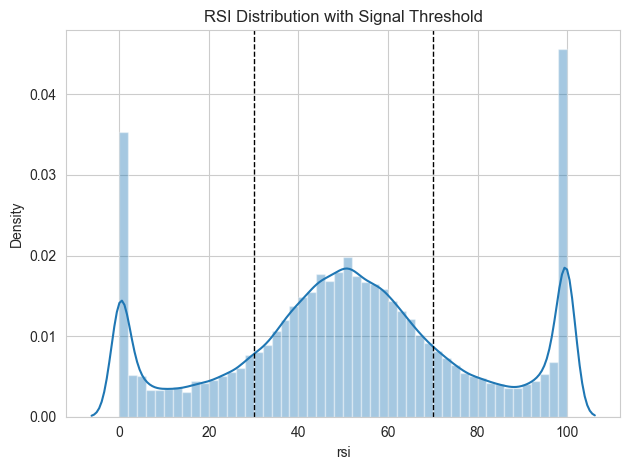

In [21]:
ax = sns.distplot(prices.rsi.dropna())
ax.axvline(30, ls='--', lw=1, c='k')
ax.axvline(70, ls='--', lw=1, c='k')
ax.set_title('RSI Distribution with Signal Threshold')
plt.tight_layout();

## Compute bollinger bands

In [22]:
def compute_bb(x, window=20):
    high, mid, low = BBANDS(
        x.values,
        timeperiod=window
    )
    return pd.DataFrame(
        {
            "bb_high": high,
            "bb_low": low
        },
        index=x.index
    )

In [23]:
def compute_bb(x, window=20):
    high, mid, low = BBANDS(
        x.values,
        timeperiod=window
    )
    return pd.DataFrame(
        {
            "bb_high": high,
            "bb_low": low
        },
        index=x.index
    )

bb = (
    prices
    .groupby(level="Ticker")["Close"]
    .apply(compute_bb)
    .reset_index(level=0, drop=True)
)

In [24]:
prices = prices.join(bb)

In [25]:
prices['bb_high'] = prices.bb_high.sub(prices.Close).div(prices.bb_high).apply(np.log1p)
prices['bb_low'] = prices.Close.sub(prices.bb_low).div(prices.Close).apply(np.log1p)

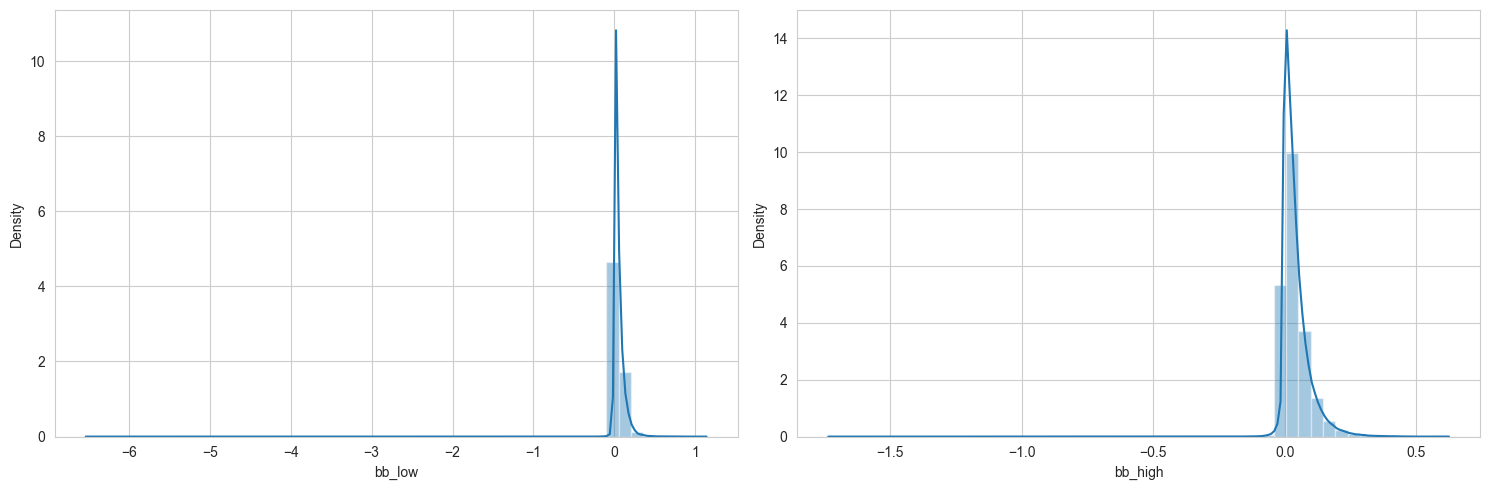

In [26]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 5))
sns.distplot(prices.loc[prices.peso_vol_rank<100, 'bb_low'].dropna(), ax=axes[0])
sns.distplot(prices.loc[prices.peso_vol_rank<100, 'bb_high'].dropna(), ax=axes[1])
plt.tight_layout();

## Compute average True range

In [27]:
def compute_atr(stock_data):
    df = ATR(stock_data.High, stock_data.Low, 
             stock_data.Close, timeperiod=14)
    return df.sub(df.mean()).div(df.std())

In [28]:
prices['atr'] = (prices.groupby('Ticker', group_keys=False)
                 .apply(compute_atr))

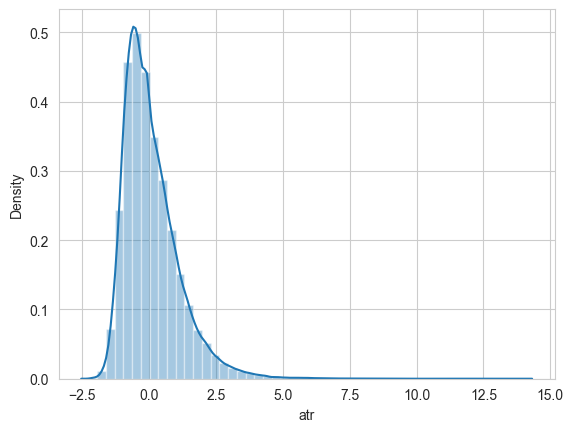

In [29]:
sns.distplot(prices[prices.peso_vol_rank<50].atr.dropna());

## Compute Moving Average Convergence/Divergence

In [30]:
def compute_macd(close):
    macd = MACD(close)[0]
    return (macd - np.mean(macd))/np.std(macd)

prices['macd'] = (prices
                  .groupby('Ticker', group_keys=False)
                  .Close
                  .apply(compute_macd))

In [31]:
prices.macd.describe(percentiles=[.001, .01, .02, .03, .04, .05, .95, .96, .97, .98, .99, .999]).apply(lambda x: f'{x:,.1f}')

count    441,366.0
mean          -0.0
std            1.0
min          -11.1
0.1%          -5.1
1%            -2.6
2%            -2.1
3%            -1.8
4%            -1.6
5%            -1.4
50%           -0.1
95%            1.6
96%            1.8
97%            2.0
98%            2.4
99%            3.2
99.9%          6.9
max           16.5
Name: macd, dtype: object

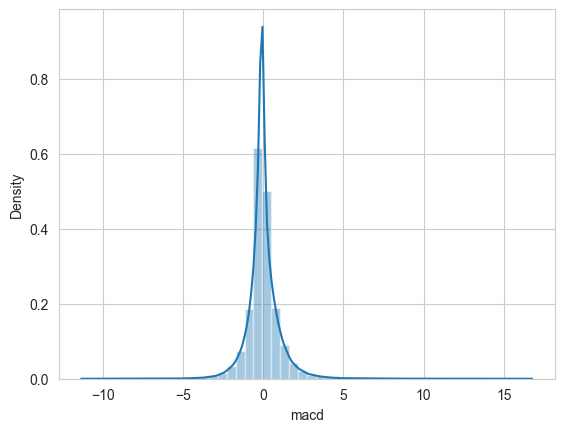

In [32]:
sns.distplot(prices[prices.peso_vol_rank<100].macd.dropna());

## Compute Lagged Returns

In [33]:
lags = [1, 2, 5, 10, 21, 42, 63]

In [34]:
returns = prices.groupby(level='Ticker').Close.pct_change()
percentiles=[.0001, .001, .01]
percentiles += [1-p for p in percentiles]
percentiles

[0.0001, 0.001, 0.01, 0.9999, 0.999, 0.99]

In [35]:
returns.describe(percentiles=percentiles).iloc[2:].to_frame('percentiles').style.format(lambda x: f'{x:,.2%}')

,percentiles
std,2.12%
min,-77.38%
0.01%,-30.15%
0.1%,-12.50%
1%,-4.59%
50%,0.00%
99%,5.30%
99.9%,14.90%
99.99%,49.84%
max,330.00%


In [36]:
q = 0.0001

### Winsorize outliers

In [37]:
for lag in lags:
    prices[f'return_{lag}d'] = (prices.groupby(level='Ticker').Close
                                .pct_change(lag)
                                .pipe(lambda x: x.clip(lower=x.quantile(q),
                                                       upper=x.quantile(1 - q)))
                                .add(1)
                                .pow(1 / lag)
                                .sub(1)
                                )

### Shift lagged returns

In [40]:
for t in [1, 2, 3, 4, 5]:
    for lag in [1, 5, 10, 21]:
        prices[f'return_{lag}d_lag{t}'] = (prices.groupby(level='Ticker')
                                           [f'return_{lag}d'].shift(t * lag))

### Compute Forward Returns

In [45]:
for t in [1, 5, 10, 21]:
    prices[f'target_{t}d'] = prices.groupby(level='Ticker')[f'return_{t}d'].shift(-t)

## Combine Price and Meta Data

In [40]:
stocks

,sector,marketCap,ipoYear
Ticker,,,
AGUAS-A.SN,utilities_&_energy,2.295713e+12,2000
ALMENDRAL.SN,telecom_&_technology,5.675538e+11,2000
ANTARCHILE.SN,industrials,3.813507e+12,2000
AZUL-AZUL.SN,consumer_discretionary,2.234167e+10,2008
BANVIDA.SN,financials,1.080044e+12,2000
...,...,...,...
VENTANAS.SN,industrials,1.732147e+11,2000
VOLCAN.SN,industrials,2.437500e+11,2000
VSPT.SN,consumer_staples,1.590794e+11,2000


In [41]:
prices = prices.join(stocks[['sector']])

## Create time and sector dummy variables

In [42]:
prices['year'] = prices.index.get_level_values('Date').year
prices['month'] = prices.index.get_level_values('Date').month
prices['weekday'] = prices.index.get_level_values('Date').weekday

In [43]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 445227 entries, ('AGUAS-A.SN', Timestamp('2010-01-01 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-30 00:00:00'))
Data columns (total 48 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Open             445227 non-null  float64
 1   High             445227 non-null  float64
 2   Low              445227 non-null  float64
 3   Close            445227 non-null  float64
 4   Volume           445227 non-null  float64
 5   peso_vol         445227 non-null  float64
 6   peso_vol_1m      442887 non-null  float64
 7   peso_vol_rank    442887 non-null  float64
 8   rsi              443589 non-null  float64
 9   bb_high          443004 non-null  float64
 10  bb_low           443000 non-null  float64
 11  atr              443589 non-null  float64
 12  macd             441366 non-null  float64
 13  return_1d        445110 non-null  float64
 14  return_2d        444993 non-null  float64
 15

In [44]:
prices.assign(sector=pd.factorize(prices.sector, sort=True)[0]).to_hdf(path_data, 'model_data/no_dummies')

In [45]:
prices = pd.get_dummies(prices,
                        columns=['year', 'month', 'weekday', 'sector'],
                        prefix=['year', 'month', 'weekday', ''],
                        prefix_sep=['_', '_', '_', ''],
                        drop_first=True,
                        dtype='uint8')

In [46]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 445227 entries, ('AGUAS-A.SN', Timestamp('2010-01-01 00:00:00')) to ('ZOFRI.SN', Timestamp('2025-12-30 00:00:00'))
Data columns (total 83 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Open                  445227 non-null  float64
 1   High                  445227 non-null  float64
 2   Low                   445227 non-null  float64
 3   Close                 445227 non-null  float64
 4   Volume                445227 non-null  float64
 5   peso_vol              445227 non-null  float64
 6   peso_vol_1m           442887 non-null  float64
 7   peso_vol_rank         442887 non-null  float64
 8   rsi                   443589 non-null  float64
 9   bb_high               443004 non-null  float64
 10  bb_low                443000 non-null  float64
 11  atr                   443589 non-null  float64
 12  macd                  441366 non-null  float64
 13  return_1d        

# Store model data

In [47]:
prices.to_hdf(path_data, 'model_data')

# Explore Data

### Plot Factors

In [48]:
target = 'target_5d'
top50 = prices[prices.peso_vol_rank<50].copy()

### RSI

In [49]:
top50.loc[:, 'rsi_signal'] = pd.cut(top50.rsi, bins=[0, 30, 70, 100])

In [50]:
top50.groupby('rsi_signal')['target_5d'].describe()

,count,mean,std,min,25%,50%,75%,max
rsi_signal,,,,,,,,
"(0, 30]",16659.0,0.000140,0.011943,-0.110188,-0.004204,0.0,0.004177,0.128331
"(30, 70]",161863.0,0.000144,0.008259,-0.110910,-0.003663,0.0,0.003755,0.181105
"(70, 100]",24578.0,0.001052,0.008705,-0.110910,-0.002802,0.0,0.004475,0.111927


### Bollinger Bands

1.70% (0.00%)


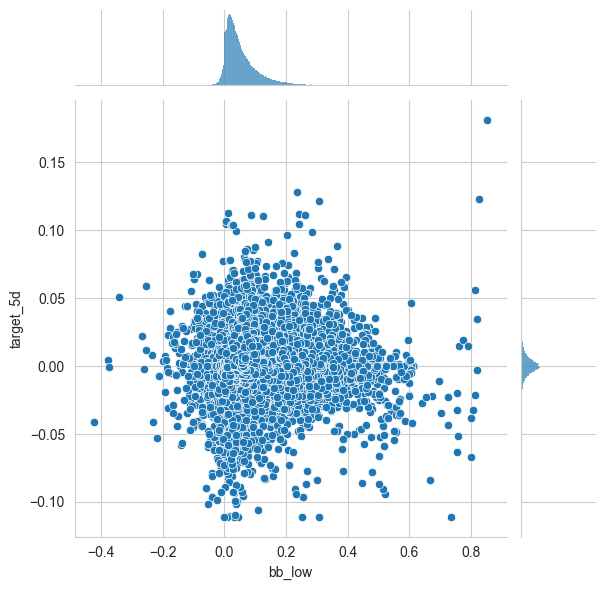

In [51]:
metric = 'bb_low'
j=sns.jointplot(x=metric, y=target, data=top50)

df = top50[[metric, target]].dropna()
r, p = spearmanr(df[metric], df[target])
print(f'{r:,.2%} ({p:.2%})')

-3.08% (0.00%)


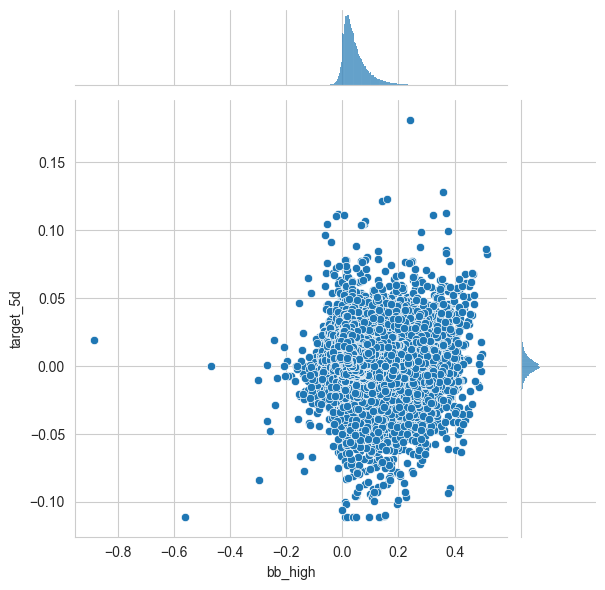

In [52]:
metric = 'bb_high'
j=sns.jointplot(x=metric, y=target, data=top50)

df = top50[[metric, target]].dropna()
r, p = spearmanr(df[metric], df[target])
print(f'{r:,.2%} ({p:.2%})')

### ATR

-3.05% (0.00%)


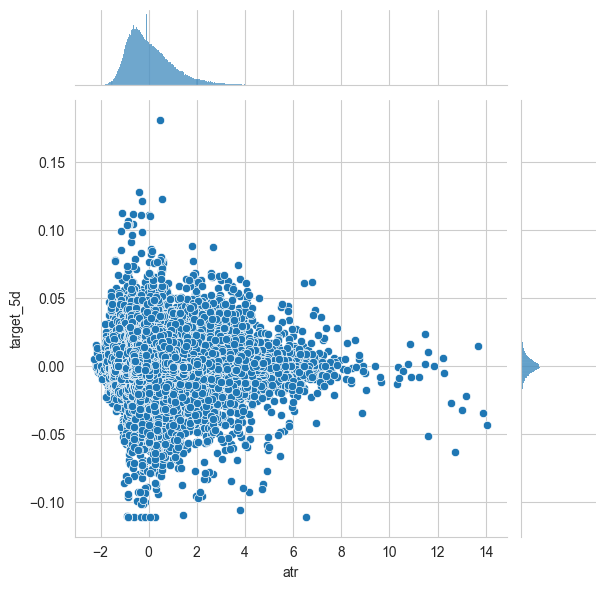

In [53]:
metric = 'atr'
j=sns.jointplot(x=metric, y=target, data=top50)

df = top50[[metric, target]].dropna()
r, p = spearmanr(df[metric], df[target])
print(f'{r:,.2%} ({p:.2%})')

### MACD

1.83% (0.00%)


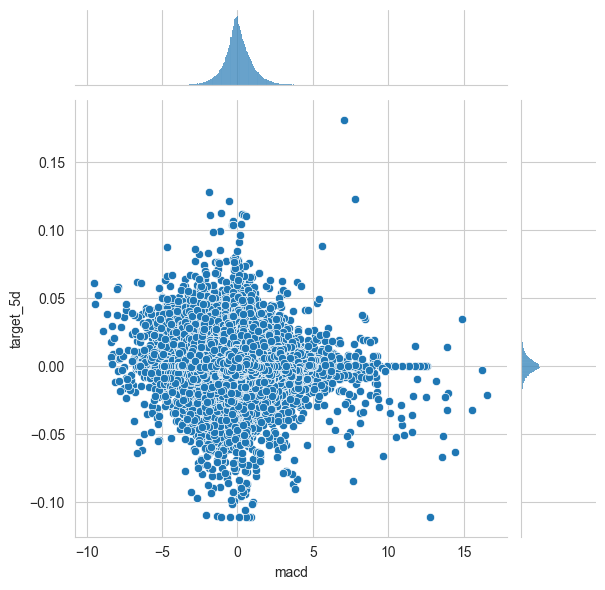

In [54]:
metric = 'macd'
j=sns.jointplot(x=metric, y=target, data=top50)

df = top50[[metric, target]].dropna()
r, p = spearmanr(df[metric], df[target])
print(f'{r:,.2%} ({p:.2%})')